In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error

In [2]:
df = pd.read_excel("Bengaluru_House_Datastudent.csv.xlsx")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  object 
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(2), str(4)
memory usage: 936.7+ KB


In [3]:
df.isnull().sum()  
# 

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,2026-12-19 00:00:00,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
print(df.columns)

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')


In [6]:
#Drop unwanted columns
df=df.drop(['area_type','society','balcony','availability'],axis=1) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(1), str(2)
memory usage: 520.4+ KB


In [7]:
print(df.columns)

Index(['location', 'size', 'total_sqft', 'bath', 'price'], dtype='str')


In [8]:
#Handling Missing values in location
df['location'].value_counts()   #count how many times each unique value appears
#white field and sarjapur are having highest values we can replace with any one of them. Here we are replacing with Sarjapur Road
df['location']=df['location'].fillna('Sarjapur Road') 
#fills all missing (NaN) values with Sarjapur Road  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(1), str(2)
memory usage: 520.4+ KB


In [9]:
#Handling missing values in size
df['size'].value_counts()  #2 BHK count is more
df['size']=df['size'].fillna('2 BHK')  #fills all missing (NaN) values with 2 BHK           
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(1), str(2)
memory usage: 520.4+ KB


In [10]:
#Handling missing values in bath
df['bath']=df['bath'].fillna(df['bath'].median())  #fills all missing (NaN) values with median value of bath column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(1), str(2)
memory usage: 520.4+ KB


In [11]:
#clean size column and convert into integer
df['size'].unique()  #check unique values in size column
out=[int(i.split()[0]) for i in df['size']]  #split the string and take first value and convert into integer    
#['2','BHK'] => 2
df['bhk']=out
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(2), int64(1), object(1), str(2)
memory usage: 624.5+ KB


In [12]:
#outliers
df[df['bhk']>20]  #check for bhk greater than 20
 

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [13]:
def convert(a):
    if isinstance(a, (int, float)):
        return float(a)

    a = str(a)

    if '-' in a:
        l = a.split('-')
        try:
            return (float(l[0]) + float(l[1])) / 2
        except:
            return None

    try:
        return float(a)
    except:
        return None

In [14]:
df['total_sqft'] = df['total_sqft'].apply(convert)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13274 non-null  float64
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 624.5 KB


In [15]:
# Price per square foot
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

# Display the new column
df['price_per_sqft'] 

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 13320, dtype: float64

In [16]:
#cleaning location column
df['location'] = df['location'].apply(lambda x: x.strip())  #removes leading and trailing spaces
#The apply() function applies a given function to every value in a column. In this case, we are using a lambda function to strip leading and trailing spaces from each value in the 'location' column.
#strip() removes unwanted spaces from the beginning and end of a string. It does not remove spaces between words.
df['location'].value_counts()  #check unique values in location column  
loc_lessthan_10 = df['location'].value_counts()
loc_lessthan_10=loc_lessthan_10[loc_lessthan_10<=10]  #check unique values in location column which are less than 10
loc_lessthan_10

location
Ganga Nagar                                        10
Dairy Circle                                       10
Sadashiva Nagar                                    10
Naganathapura                                      10
Nagappa Reddy Layout                               10
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1054, dtype: int64

In [17]:
df['location'] = df['location'].apply(lambda x: 'other' if x in loc_lessthan_10 else x)  #replace all locations which are less than 10 with other

In [18]:
df.describe()  #gives count, mean, std, min, 25%, 50%, 75%, max values of all columns       

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [19]:
#Total sqrt.fit per bhk
(df['total_sqft']/df['bhk']).describe()  #gives count, mean, std, min, 25%, 50%, 75%, max values of all columns     

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [20]:
df=df[df['total_sqft']/df['bhk']>=300] #filtering the data where total_sqft/bhk is less than 300
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [21]:
df=df[df['total_sqft']>=df['bhk']*300] #filtering the data where total_sqft is less than bhk*300
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


<Axes: xlabel='price_per_sqft'>

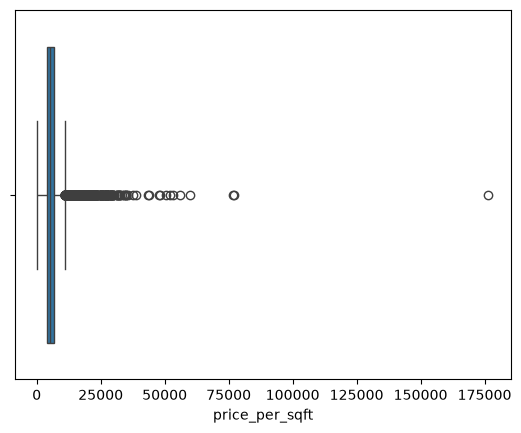

In [22]:
sns.boxplot(x='price_per_sqft',data=df)  #boxplot of price_per_sqft column

In [23]:
q1=df['price_per_sqft'].quantile(0.25) #calculates the 25th percentile of the price_per_sqft column
q3=df['price_per_sqft'].quantile(0.75) #calculates

IQR=q3-q1 #calculates the interquartile range (IQR) of the price_per_sqft column
lower_bound=q1-0.5*IQR
upper_bound=q3+0.5*IQR
df=df[(df['price_per_sqft']>=lower_bound) & (df['price_per_sqft']<=upper_bound)] #filtering the data where price_per_sqft is less than lower_bound and greater than upper_bound 
df.info()

<class 'pandas.DataFrame'>
Index: 10350 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        10350 non-null  str    
 1   size            10350 non-null  str    
 2   total_sqft      10350 non-null  float64
 3   bath            10350 non-null  float64
 4   price           10350 non-null  float64
 5   bhk             10350 non-null  int64  
 6   price_per_sqft  10350 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 646.9 KB


<Axes: xlabel='price_per_sqft'>

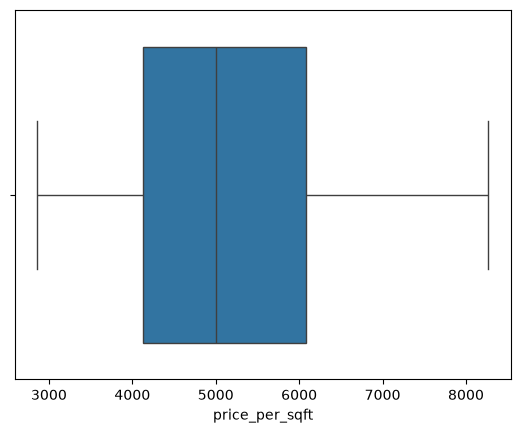

In [24]:
sns.boxplot(x='price_per_sqft',data=df)  #boxplot for price_per_sqft column

In [25]:
df=df[df['bhk']<=6]

In [26]:
#handling outliers in bath column
df=df[df['bath']<df['bhk']+2] #filtering the data where bath is greater than bhk+2
#it removes unrealistic data points where the number of bathrooms is significantly higher than the number of bedrooms, which could indicate data entry errors or unusual properties. This helps to improve the quality of the dataset for analysis and modeling.    
#(bath) is suspiciously high compared to the number of bedrooms (bhk), which is not typical in most residential properties. By filtering out these outliers, we can ensure that the dataset is more representative of typical housing conditions and improve the accuracy of any analysis or modeling performed on the data.

In [27]:
df=df.drop(['size','price_per_sqft'],axis=1)  #drop size and price_per_sqft columns 
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [31]:
df.reset_index(inplace=True)  #reset index of the dataframe and drop the old index column    
df=df.drop('index',axis=1)  #drop index column    

In [32]:
cleaned=df.copy()

In [40]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder() 
df['location']=encoder.fit_transform(cleaned[['location']])

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
X=df.drop('price',axis=1)  #drop price column from dataframe and assign to x
y=df['price']

In [47]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42) #splits the dataset into training and testing sets, with 20% of the data reserved for testing. The random_state parameter ensures that the split is reproducible.

In [49]:
model=RandomForestRegressor(random_state=42)  #create a RandomForestRegressor model
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6]

}
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)  #create a GridSearchCV object with model, params, cv=5 and scoring='r2'
grid.fit(Xtrain,ytrain)  #fit the grid object with x and y

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [50]:
print("Best params: ",grid.best_params_) 
print("Best score: ",grid.best_score_)

Best params:  {'max_depth': 6, 'n_estimators': 300}
Best score:  0.834481624803891


In [51]:
print("Training Eff:",grid.score(Xtrain,ytrain)) #Training Efficiency
print("Testing Eff:",grid.score(Xtest,ytest)) #Testing Efficiency

Training Eff: 0.8840956558695535
Testing Eff: 0.8415605487128904


In [52]:
ypred=grid.predict(Xtest)

In [53]:
print("R2 score: ",r2_score(ytest,ypred)) #R2 score is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model. It provides an indication of goodness of fit and therefore a measure of how well unseen sam
print('MAE',mean_absolute_error(ytest,ypred)) #MAE is a measure of the average magnitude of the errors in a set of predictions, without considering their direction. It is the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

R2 score:  0.8415605487128904
MAE 13.957439732473782


In [54]:
with open('RFmodel.pkl','wb') as file:  #save the model as a pickle file
    pickle.dump(grid,file)  #dump the grid object into the file

In [55]:
df.head()

,location,total_sqft,bath,price,bhk
0,78,1056.0,2.0,39.07,2
1,60,2600.0,5.0,120.00,4
2,225,1440.0,2.0,62.00,3
3,158,1521.0,3.0,95.00,3
4,150,1200.0,2.0,51.00,2


In [56]:
cleaned['encoded_loc']=df['location']

In [57]:
df.describe()

,location,total_sqft,bath,price,bhk
count,10230.000000,10230.00000,10230.000000,10230.000000,10230.000000
mean,151.842717,1432.13379,2.367937,76.218467,2.495992
std,76.392610,773.66501,0.779985,54.319457,0.753740
min,0.000000,300.00000,1.000000,10.000000,1.000000
25%,92.000000,1100.00000,2.000000,47.000000,2.000000
50%,160.000000,1256.50000,2.000000,64.000000,2.000000
75%,234.000000,1577.00000,3.000000,89.112500,3.000000
max,240.000000,30400.00000,7.000000,2100.000000,6.000000


In [59]:
df.bath.unique()

array([2., 5., 3., 4., 1., 6., 7.])

In [61]:
df.shape

(10230, 5)